# **Embedding Classification**

#To be filled <short assignment description>

This work in done by :
- Tejas Phanse
- Jaee Oh
- Mandadi Ayush Reddy

---------

### **Set-Up**

This section focuses on loading the data, python libraries (which will be used throughout this notebook)

In [1]:
# Loading Libraries
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

# Trainging Word2Vec CBOW Model
from gensim.models import Word2Vec

import umap

print("--"*50)
print("Libraries loaded successfully.")
print("--"*50)

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----------------------------------------------------------------------------------------------------
Libraries loaded successfully.
----------------------------------------------------------------------------------------------------


In [2]:
# Loading the dataset
data = pd.read_csv("data/english_pages_metadata_clean_with_labels.csv")
print("--"*50)
print("First few Rows of the Dataset:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
First few Rows of the Dataset:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,both
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,both
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,both
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,both
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...",both
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,both
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,both
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,both
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,both


In [3]:
data_og = pd.read_csv("data/dataset_with_assignments.csv")

analysis_df = data_og[["page_id", "full_text"]].copy()

print("--"*50)
print("First few Rows of the Original Complete Dataset:")
print("--"*50)
analysis_df

----------------------------------------------------------------------------------------------------
First few Rows of the Original Complete Dataset:
----------------------------------------------------------------------------------------------------


,page_id,full_text
0,1,Best Resume Templates 2024 | Ready to Download...
1,4,SH/SZ-HK Stock Connect Quick Quote\n繁\n简\nMark...
2,6,A.D.A. Amiga Demoscene Archive\nA.D.A. Amiga D...
3,7,"Time, Mortality And Memory - blog from trends\..."
4,8,AFR News: JurisDictionary- How Your Constituti...
...,...,...
6309,8259,April 2022 Newsletter – Zettel Family Farms\nS...
6310,8261,PONDS BRIGHT BEAUTY SPOT-LESS GLOW FACEWASH 50...
6311,8262,Understanding Bitcoin And Its Market Trends Ho...
6312,8264,Woman and Dog Wood Figurine | Z Man's Wood Art...


## **Part A) Document-Term Matrix Creation**

Using the techniques from the lab sessions, create a Document-Term Matrix (DTM) with TF-IDF weights for the entire Common Crawl dataset 


### **1. Text Preprocessing**

In this section, the primary focus is on cleaning the text data.Identifying and removing these characters early is important, as they can cause issues later in the pipeline and can negatively impact stability and compatibility. The primary goal here is to retain ASCII characters, such as English letters, numbers, and common punctuation (e.g., '(', ')', '[', ']', '+', '-', ' '), while ensuring that the existing structure of the text remains unchanged.

In [4]:
# list of currency symbols (few of them might not be present, but still we will keep it)
currency_symbols = [
    # Paired (Multi-character) symbols (Longest first)
    'USD','AU$', 'C$', 'NZ$', 'HK$', 'S$', 'US$', 'NT$', 'MX$', 'R$', 'zł', 'Kč','₨',
    'kr', 'Ft', 'ден', 'р.', 'лв', '₡', '₢', '₣', '₥', 

    # Single character symbols (Specific before generic)
    '€', '£', '¥', '元', '₹', '฿', '₩', '₽', '₪', '₺', '₦', '₵', '₫', 
    '₱', '₭', '₮', '₼', '₸', '₴', '៛', '₲', '₡', '₾', '֏', '﷼', 'Ξ', 'Ł', '$'
]

curr_symbols = ''.join(re.escape(s) for s in currency_symbols)

In [5]:
# Text cleaning function
def full_text_clean(text):

    # Regex pattern for extracting emails
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

    # Regex pattern for extracting phone numbers (various formats)
    phone_pattern = r'\b(?:\+\d{1,3}[-\s]?)?(?:\(\d{3}\)|\d{3})[-\s]?\d{3,4}[-\s]\d{4}\b'

    # Regex pattern for extracting dates (various formats)
    date_pattern = r'\b(?:\d{4}[-.]\d{2}[-.]\d{2}|\d{2}[-/]\d{2}[-/]\d{4}|(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s\d{1,2},\s\d{4}|\d{1,2}\s(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\.?\s\d{4})\b'

    # Regex pattern for extracting URLs
    url_pattern = r'https?://\S+|www\.\S+'

    # Applying the patterns on the text
    text = re.sub(email_pattern, '', text)
    text = re.sub(phone_pattern, '', text)
    text = re.sub(date_pattern, '', text)
    text = re.sub(url_pattern, '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[_\-/|]', ' ', text)
    text = text.lower()
    text = re.sub(rf"[^a-z{curr_symbols}\s]", '', text)
    text=re.sub(r'[^\w\s]+', '', text)

    return text

In [6]:
# Data Cleaning and Preprocessing
data['cleaned_text'] = data['full_text'].apply(full_text_clean)
analysis_df['cleaned_text'] = analysis_df['full_text'].apply(full_text_clean)

print("--"*50)
print("Data cleaning and preprocessing completed successfully.")
print("--"*50)
# Displaying the cleaned text
analysis_df[['page_id', 'cleaned_text']]

----------------------------------------------------------------------------------------------------
Data cleaning and preprocessing completed successfully.
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text
0,1,best resume templates ready to download k...
1,4,sh sz hk stock connect quick quote\n\n\nmarket...
2,6,ada amiga demoscene archive\nada amiga demosce...
3,7,time mortality and memory blog from trends\n...
4,8,afr news jurisdictionary how your constitutio...
...,...,...
6309,8259,april newsletter zettel family farms\nskip t...
6310,8261,ponds bright beauty spot less glow facewash g ...
6311,8262,understanding bitcoin and its market trends ho...
6312,8264,woman and dog wood figurine z mans wood art ...


In [7]:
print("--"*50)
print("First few Rows of the Cleaned Text from the Labeled Dataset:")
print("--"*50)
# Displaying the cleaned text
data[['page_id', 'cleaned_text', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
First few Rows of the Cleaned Text from the Labeled Dataset:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,BLOG
2,657.0,booking report for bulloch county allongeor...,NEWS
3,658.0,is pickleball easier than tennis allracket\n...,BLOG
4,661.0,account executive auto finance greater seatt...,OTHER
...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,BLOG
592,490.0,kids bike pedals collection d model in bicycle...,ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,OTHER


In [8]:
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (382) 
-- Total Characters length before cleaning: 563 
-- Total Character Length  after cleaning: 528
----------------------------------------------------------------------------------------------------


### **2. Removal of Stop Words**

These are common repeating words in a sentence, such as “a,” “the,” “he,” and “there.” These words typically carry little semantic meaning on their own, as they primarily serve grammatical functions. In this assignment, where our goal is to identify meaningful classification terms, such stopwords would dominate the corpus because they appear in nearly all sentences, thereby adding noise rather than useful information.

In [9]:
# loading stopwords from both sklearn and nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)
nltk_unique = nltk_stopwords.difference(sklearn_stopwords)

# List of common words to be removed from full_text_clean column
common_word_list = {'followers', 'instagram', 'facebook', 'like', 'messages', 'support',
                    'sitemap', 'free', 'faq', 'twitter', 'search', 'subscribe', 'youtube', 
                    'feedback', 'linkedin', 'demo', 'menu', 'following', 'unsubscribe', 
                    'snapchat', 'tiktok', 'whatsapp', '1xbet',
                    'profile', 'share', 'reddit', 'download', 'settings', 'notifications', 'qa', 'people'}

# Common phrases to remove
phrase_list = ["find out more", "join now","terms & conditions", "terms and conditions","all rights reserved","free trial", 
             "click here", "about us", "contact us","terms of service", "privacy policy", "help center", "our story","our team",
             "read more", "learn more", "get started", "download now", "sign up", "log in", 'december december']

stop_words_corpus = sklearn_stopwords.union(nltk_unique).union(common_word_list).union(phrase_list)

print("--"*50)
print("Total Stop Words in the Corpus:", len(stop_words_corpus), "\nSample Stop Words:", list(stop_words_corpus)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Total Stop Words in the Corpus: 449 
Sample Stop Words: ['besides', 'always', 'yourselves', 'four', 'mostly', "we've", 'although', 'sign up', 'has', "that'll"] ...
----------------------------------------------------------------------------------------------------


In [10]:
# Stopwords Removal
def remove_stop_words(text):
    clean_text = []
    for word in text.split():
        if word not in stop_words_corpus:
            clean_text.append(word)
    
    return ' '.join(clean_text)

In [11]:
data['stopwords_removed'] = data['cleaned_text'].apply(remove_stop_words)
analysis_df['stopwords_removed'] = analysis_df['cleaned_text'].apply(remove_stop_words)

In [12]:
idx = np.random.randint(0, 596)

print("--"*50)
print(f"Text Field ({idx}) \n-- Total Characters length before cleaning: {len(data.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(data.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Text Field (355) 
-- Total Characters length before cleaning: 2462 
-- Total Character Length  after cleaning: 2306
----------------------------------------------------------------------------------------------------


In [13]:
print("--"*50)
print(f"Original Text Field ({idx}) \n-- Total Characters length before cleaning: {len(analysis_df.loc[idx, 'full_text'])} \n-- Total Character Length  after cleaning: {len(analysis_df.loc[idx, 'cleaned_text'])}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Original Text Field (355) 
-- Total Characters length before cleaning: 3863 
-- Total Character Length  after cleaning: 3639
----------------------------------------------------------------------------------------------------


In [14]:
sentences = analysis_df['cleaned_text'].tolist()

# Find total number of tokens
total_tokens = sum(len(s) for s in sentences)

# Find average number of tokens per document
avg_tokens = np.mean([len(s) for s in sentences])

print("--"*50)
print("Preprocessing completed. Sample of cleaned text:")
print("--"*50)
print(f"Total number of tokens in the corpus: {total_tokens}")
print(f"Average number of tokens per document: {avg_tokens}")
print(f"First 5 words in First Document: {sentences[0][:5]}")  # Print first 5 tokens of the first document
print(f"First 5 words in Second Document: {sentences[1][:5]}")  # Print first 5 tokens of the second document

----------------------------------------------------------------------------------------------------
Preprocessing completed. Sample of cleaned text:
----------------------------------------------------------------------------------------------------
Total number of tokens in the corpus: 40666900
Average number of tokens per document: 6440.750712701933
First 5 words in First Document: best 
First 5 words in Second Document: sh sz


### **3. Word2Vec Training**

#### **3.1 Word2Vec Training - CBOW**

In [15]:
complete_corpus = analysis_df['cleaned_text'].str.split().tolist()

In [16]:
print(len(complete_corpus))
print(complete_corpus[0][:10])  # Print first 10 tokens of the first document in complete corpus

6314
['best', 'resume', 'templates', 'ready', 'to', 'download', 'kickresume', 'we', 'use', 'cookies']


In [17]:
start_time = time.time()

cbow_model = Word2Vec(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=0               # CBOW
)
time_cbow = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for Word2Vec CBOW: {time_cbow:.4f} seconds")
print("Model Content:", cbow_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


----------------------------------------------------------------------------------------------------
Elapsed time for Word2Vec CBOW: 17.8608 seconds
Model Content: Word2Vec<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [18]:
word_matrix = pd.DataFrame(
    cbow_model.wv.vectors,
    index=cbow_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the Word2Vec CBOW Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the Word2Vec CBOW Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-0.325301,-1.590413,1.577202,0.306008,-1.036676,-0.296992,-0.484241,0.718378,0.308345,-1.266034,...,-0.419533,-1.249199,0.203617,-0.672794,1.108711,-2.480337,0.948352,-0.049492,-0.754692,1.149222
and,0.205846,-0.657412,-0.218424,0.189756,-0.677614,-0.424381,-0.488534,-1.426872,-0.140171,-0.627984,...,0.192100,-0.948338,0.515499,0.142118,1.290202,-1.326220,0.522864,-0.488742,-0.283779,0.266038
to,-0.109492,0.315838,0.895768,0.707495,0.604901,-0.554059,-0.167756,-0.609185,0.499165,0.223929,...,-0.556634,-0.173663,1.082922,0.614057,1.431457,-0.821056,0.721189,0.760048,0.459036,1.905966
of,-0.601542,-0.720588,0.105859,0.027652,-0.592915,-0.410566,0.678653,-1.490652,-1.093047,0.443909,...,-0.871512,-1.209975,1.990437,-0.063005,0.997335,-0.071764,-1.169371,0.441137,-0.985554,0.940948
a,-0.676810,-0.374728,1.584642,0.782384,-0.661592,2.016815,-0.746009,-1.616855,0.883821,-1.034105,...,-1.121644,-0.172369,-0.484877,0.591983,1.454086,-1.062300,-0.342477,1.676007,1.154070,2.288789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.028422,-0.044781,0.056919,0.087195,0.031714,-0.175825,-0.009657,0.082275,-0.182238,0.310169,...,-0.090466,0.087609,-0.013941,0.088401,-0.075278,0.082097,0.017520,0.109476,0.020956,-0.080570
lows,-0.034591,0.046120,-0.038719,0.032282,-0.110350,-0.181342,0.272425,-0.046219,-0.183661,0.046100,...,0.162706,-0.005848,-0.056418,0.151887,0.106632,-0.111016,-0.144272,-0.082706,0.066904,0.061430
boldly,-0.084325,0.083542,-0.064414,0.171951,0.083613,0.102732,0.090961,0.010750,-0.134481,0.100145,...,-0.046884,0.063573,0.024776,-0.005014,-0.082603,-0.181069,-0.094243,0.016638,0.157054,0.012645
endings,0.106381,-0.043198,-0.015054,0.115624,-0.031286,-0.086189,-0.064672,-0.082776,-0.026672,0.201089,...,-0.036675,0.102184,-0.020071,-0.091647,-0.006437,0.033000,0.069471,-0.017905,0.176171,-0.036551


#### **3.2 Word2Vec Training - Skipgram**

In [19]:
start_time = time.time()

skipgram_model = Word2Vec(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=1               # Skipgram
)
time_sg = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for Word2Vec Skipgram: {time_sg:.4f} seconds")
print("Model Content:", skipgram_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

----------------------------------------------------------------------------------------------------
Elapsed time for Word2Vec Skipgram: 66.8764 seconds
Model Content: Word2Vec<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [20]:
word_matrix = pd.DataFrame(
    skipgram_model.wv.vectors,
    index=skipgram_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the Word2Vec Skip-gram Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the Word2Vec Skip-gram Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,0.133355,0.028190,0.109826,-0.045922,-0.173662,-0.106689,0.141522,0.195219,-0.184459,-0.238194,...,0.053290,-0.263563,-0.160044,-0.246069,0.065798,-0.157425,0.036782,0.002488,0.059752,0.294619
and,0.153171,0.003567,-0.012219,-0.112990,-0.476963,0.142465,0.136487,-0.115521,-0.141343,-0.233523,...,-0.002898,-0.213738,-0.042798,-0.038160,0.063749,0.009609,-0.019108,-0.159457,0.149491,0.229863
to,-0.022745,0.158357,0.133029,-0.156337,-0.429946,0.027317,0.318742,0.236771,-0.168081,-0.111660,...,-0.111407,-0.038962,-0.092397,-0.223453,-0.112609,-0.019743,-0.029589,0.041588,0.024418,0.302428
of,-0.030826,-0.000748,0.206372,0.059022,-0.138516,-0.040497,0.290651,0.053101,-0.042668,0.092587,...,-0.258198,-0.243318,-0.149827,0.029994,0.196365,-0.083477,-0.132892,-0.019418,-0.035271,0.172234
a,0.032910,-0.274787,-0.072290,-0.071829,0.066504,-0.189175,0.141777,0.174322,-0.361425,-0.155508,...,-0.190160,-0.125844,-0.124175,-0.097452,-0.056201,-0.154615,-0.233322,0.311226,0.129672,0.283688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.132880,-0.273686,0.039201,0.081268,-0.060453,0.110895,0.105169,0.194799,0.024412,0.335553,...,0.042389,-0.206908,-0.375178,-0.552424,0.006849,-0.244743,0.018839,-0.098536,-0.033083,-0.009597
lows,-0.047567,0.004268,0.081152,0.082383,-0.193645,-0.322830,0.597885,-0.085300,-0.321924,-0.119434,...,0.059334,0.006126,-0.092034,-0.080111,0.198936,-0.001560,-0.104238,0.062279,0.028832,-0.000065
boldly,-0.126778,0.282558,-0.113457,0.045631,-0.375023,-0.121044,0.164836,-0.050217,-0.221303,-0.008744,...,0.098204,-0.188795,0.151922,-0.108211,0.004956,-0.263467,0.024984,-0.037434,0.301138,0.205527
endings,-0.069755,0.154708,-0.066329,0.087986,-0.102555,-0.200115,0.019897,-0.136850,-0.084254,0.043372,...,-0.070052,-0.154218,-0.205923,-0.329089,0.183003,0.048997,-0.033971,-0.074467,0.093820,0.066186


### **4 FastText Training**

In [21]:
from gensim.models import FastText

#### **4.1 Fasttext - CBOW**

In [22]:
start_time = time.time()

ftcbow_model = FastText(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=0,              # CBOW
    min_n=3,           # min n-gram length
    max_n=7            # max n-gram length
)
time_ftcbow = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for FastText CBOW: {time_ftcbow:.4f} seconds")
print("Model Content:", ftcbow_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


----------------------------------------------------------------------------------------------------
Elapsed time for FastText CBOW: 102.3790 seconds
Model Content: FastText<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [23]:
word_matrix = pd.DataFrame(
    ftcbow_model.wv.vectors,
    index=ftcbow_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the FastText CBOW Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the FastText CBOW Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-0.836940,1.108310,-1.519217,-0.279946,-3.185580,-1.614882,-1.408090,2.007144,0.490277,-2.568862,...,0.403821,-0.612223,-0.226168,-2.499783,1.594559,-0.657302,-0.760087,0.721008,0.781744,1.111847
and,-1.056721,-1.715677,0.357588,-1.463179,-0.534732,0.576930,-0.876064,3.066957,0.216960,0.300458,...,1.257803,1.521991,-0.128036,-0.255761,-1.449759,0.056435,-1.625748,-3.803345,1.189641,2.978872
to,3.150972,-1.110021,-4.984019,0.393537,-3.003846,2.852457,-4.675096,3.021268,5.404492,-3.803712,...,-4.207736,2.706130,-3.333288,0.008797,2.594986,2.509803,4.225792,-4.592488,-4.032108,3.458686
of,-2.148933,1.424013,1.665998,2.335582,-3.730450,2.875584,1.118725,1.855561,2.892717,0.613578,...,1.901543,4.307148,5.779448,3.908439,-4.110466,3.670742,-2.565733,-9.518169,-5.177898,2.760612
a,-0.483499,1.218464,-4.942141,3.772813,3.489119,-7.457855,3.987802,4.738912,-5.810116,-2.864129,...,-13.733612,-4.318830,-4.980138,-5.107738,9.061773,-1.058568,-8.409868,3.743192,1.789177,6.011715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.767805,-0.323639,-0.936179,-0.329968,0.106204,1.173197,1.730664,0.875994,0.271601,-0.749676,...,-1.229880,0.060340,0.584550,0.373808,1.134764,0.587997,-1.464375,1.115127,-1.307442,-0.333208
lows,1.022182,1.147644,-2.717303,0.464913,-0.534350,0.863117,0.092339,-0.129591,0.827768,-0.842718,...,-1.539327,-0.172257,0.525724,0.317103,-0.381909,0.192458,-0.013093,-0.402724,0.046746,1.677876
boldly,-0.683553,-0.605800,0.300941,0.145465,-0.512413,-0.130560,0.167258,1.416289,0.348433,-0.807134,...,0.146379,-0.561890,-0.352468,0.863476,-0.493038,-0.350727,-0.436834,0.500535,0.297348,0.482605
endings,0.032407,-1.482762,-1.109259,0.211528,-1.746191,-0.222200,-0.296711,0.913355,0.666031,0.681305,...,-0.108396,-0.653830,0.831338,-0.903645,0.463090,-0.688045,-1.274003,-0.770185,0.600771,0.052271


#### **4.2 Fasttext - Skipgrams**

In [24]:
start_time = time.time()

ftskipgram_model = FastText(
    sentences=complete_corpus,
    vector_size=200,   # embedding dimension
    window=5,          # context window
    min_count=10,      # ignore rare words
    workers=4,         # CPU cores
    epochs=10,         # number of training iterations
    sg=1,              # Skip-gram
    min_n=3,           # min n-gram length
    max_n=7            # max n-gram length
)
time_ftskipgram = round(time.time() - start_time, 4)

print("--"*50)
print(f"Elapsed time for FastText Skip-gram: {time_ftskipgram:.4f} seconds")
print("Model Content:", ftskipgram_model)
print("--"*50)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

----------------------------------------------------------------------------------------------------
Elapsed time for FastText Skip-gram: 144.7099 seconds
Model Content: FastText<vocab=30070, vector_size=200, alpha=0.025>
----------------------------------------------------------------------------------------------------


In [25]:
word_matrix = pd.DataFrame(
    ftskipgram_model.wv.vectors,
    index=ftskipgram_model.wv.index_to_key
)
print("--"*50)
print("First few rows of the FastText Skip-gram Word Embeddings Matrix:")
print("--"*50)
word_matrix

----------------------------------------------------------------------------------------------------
First few rows of the FastText Skip-gram Word Embeddings Matrix:
----------------------------------------------------------------------------------------------------


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-0.063468,0.053258,-0.047925,-0.058427,0.189888,-0.204961,0.389843,0.157074,-0.116621,-0.147054,...,-0.120014,-0.065220,-0.350991,0.088332,-0.077994,-0.139298,0.040577,-0.096177,-0.025201,0.053960
and,-0.043415,0.005698,0.089159,0.012123,-0.101477,-0.099626,0.085290,0.217697,0.115345,-0.294335,...,-0.028077,0.262273,-0.165131,0.098703,-0.059112,-0.085785,0.023839,0.015914,-0.042600,0.222222
to,-0.030588,-0.093397,0.016244,-0.178087,-0.036581,-0.093878,-0.070288,0.105730,-0.006173,-0.172413,...,-0.124509,0.289154,-0.055442,0.028673,0.040982,-0.070567,0.090488,-0.119085,0.125111,0.353586
of,0.068893,-0.019486,0.195709,-0.074679,-0.094334,-0.107056,0.274343,-0.002410,-0.167350,-0.126631,...,-0.276298,-0.018093,-0.251390,-0.000756,0.094936,-0.045441,0.002804,-0.101607,0.035925,0.108515
a,-0.031733,0.008081,0.113841,-0.029776,0.142960,-0.089927,-0.112270,0.149909,-0.073380,0.045329,...,-0.040712,0.030675,-0.215682,0.091563,0.057906,0.017928,-0.073115,0.019904,0.134772,0.077672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
warranted,-0.023723,-0.245547,0.160606,0.004805,0.095214,-0.196840,-0.174455,0.049206,-0.704600,0.286210,...,-0.443621,0.265270,-0.061418,0.097528,0.156051,-0.247136,0.324415,0.237672,0.117304,0.202279
lows,0.099461,0.087563,-0.208651,-0.081303,-0.316041,0.019477,-0.161194,0.023265,-0.054339,-0.558618,...,0.185240,0.309393,-0.229681,0.229137,0.087155,-0.339175,0.143645,0.187196,0.200875,0.442345
boldly,-0.144380,-0.105106,0.038837,-0.281906,-0.008130,0.248896,-0.193268,0.287431,-0.101808,-0.154253,...,-0.183253,-0.039181,0.055536,-0.138603,0.233764,-0.358008,-0.131629,0.311804,-0.228525,-0.013893
endings,-0.028496,-0.011068,-0.129696,-0.246177,0.200122,-0.042958,-0.117091,-0.137721,-0.081118,-0.542503,...,-0.115591,0.086158,-0.023950,0.147681,-0.080449,-0.660447,0.034996,0.223923,0.056401,0.371971


### **5. Model Summary**

Here we will see model run-time, vocabulary size and embedding dimensions

In [26]:
# Print vocabulary size and embedding dimensions
training_summary = pd.DataFrame({
    'Model':       ['Word2Vec CBOW', 'Word2Vec Skip-gram', 'FastText CBOW', 'FastText Skip-gram'],
    'Time (s)':    [time_cbow, time_sg, time_ftcbow, time_ftskipgram],
    'Vocab Size':  [len(m.wv) for m in [cbow_model, skipgram_model, ftcbow_model, ftskipgram_model]],
    'Vector Size': [m.vector_size for m in [cbow_model, skipgram_model, ftcbow_model, ftskipgram_model]],
})

print(training_summary)

                Model  Time (s)  Vocab Size  Vector Size
0       Word2Vec CBOW   17.8608       30070          200
1  Word2Vec Skip-gram   66.8764       30070          200
2       FastText CBOW  102.3790       30070          200
3  FastText Skip-gram  144.7099       30070          200


### **6. Semantic Test - Nearest Neighbours**


In [27]:
label_list = data['manual_label_final'].str.lower().unique().tolist()
label_list += ["forum","discussion","document"]

In [28]:
# CBOW Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in CBOW model:")
    if label in cbow_model.wv:
        similar_words = cbow_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in CBOW vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in CBOW model:
[('shopify', 0.6890284419059753), ('saas', 0.6692695617675781), ('prebuilt', 0.6548901796340942), ('magento', 0.6146187782287598), ('drupal', 0.6143825650215149), ('ux', 0.6141270399093628), ('prestashop', 0.60737144947052), ('elementor', 0.5973038077354431), ('joomla', 0.5797142386436462), ('freelancer', 0.5792040824890137)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in CBOW model:
[('blogs', 0.5703853964805603), ('testimonials', 0.5260812044143677), ('faq', 0.5143241882324219), ('faqs', 0.4598983824253082), ('tutorials', 0.4509308934211731), ('archive', 0.448365718126297), ('newsletter', 0.3996789753437042), ('inspiration', 0.39881631731987), ('insider', 0.39421793818473816), ('articles', 0.39341413974761963)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'news' in CBO

In [29]:
# Skipgram Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in Skipgram model:")
    if label in skipgram_model.wv:
        similar_words = skipgram_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in Skipgram vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in Skipgram model:
[('drupal', 0.5933109521865845), ('prestashop', 0.5844312310218811), ('zapier', 0.5642837285995483), ('magento', 0.5625869035720825), ('bigcommerce', 0.5467514395713806), ('xero', 0.545563817024231), ('odoo', 0.542072057723999), ('outsource', 0.5330414772033691), ('engagebay', 0.5277512669563293), ('superworks', 0.527746856212616)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in Skipgram model:
[('testimonials', 0.6502241492271423), ('blogs', 0.635191023349762), ('jtorry', 0.5999227166175842), ('delegationshared', 0.5804607272148132), ('inboxemail', 0.5763523578643799), ('whitepapers', 0.5687775611877441), ('enews', 0.5647144913673401), ('doctena', 0.5544949769973755), ('mediapost', 0.5472991466522217), ('faq', 0.5429248213768005)]
----------------------------------------------------------------------------------------------------
Top 10 similar 

In [30]:
# FastText CBOW Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in FastText CBOW model:")
    if label in ftcbow_model.wv:
        similar_words = ftcbow_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in FastText CBOW vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in FastText CBOW model:
[('bigcommerce', 0.944604218006134), ('commerce', 0.9332795739173889), ('woocommerce', 0.9124990105628967), ('commercialization', 0.6929792165756226), ('commercials', 0.6883814334869385), ('commercial', 0.6493655443191528), ('commercially', 0.6210888028144836), ('retail', 0.6139194369316101), ('noncommercial', 0.6121985912322998), ('fierce', 0.5900996923446655)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in FastText CBOW model:
[('blogs', 0.8529059886932373), ('blogosm', 0.8493480086326599), ('weblog', 0.823363721370697), ('blogroll', 0.7735052704811096), ('blob', 0.745139479637146), ('bloglovin', 0.7282344698905945), ('dlog', 0.7258291244506836), ('vlog', 0.7194067239761353), ('blogger', 0.7140867114067078), ('blox', 0.694638192653656)]
----------------------------------------------------------------------------------------------------
To

In [31]:
# FastText Skip-gram Model Semantic Test
for label in label_list:
    print(f"Top 10 similar words to '{label}' in FastText Skip-gram model:")
    if label in ftskipgram_model.wv:
        similar_words = ftskipgram_model.wv.most_similar(label, topn=10)
        print(similar_words)
    else:
        print(f"  '{label}' not found in FastText Skip-gram vocabulary.")
    print("--"*50)

Top 10 similar words to 'ecommerce' in FastText Skip-gram model:
[('bigcommerce', 0.9007850885391235), ('commerce', 0.8465156555175781), ('woocommerce', 0.7634372711181641), ('drupal', 0.6231240034103394), ('onepage', 0.5908575654029846), ('joomla', 0.5708907842636108), ('hubspot', 0.5508817434310913), ('wordpress', 0.5393573641777039), ('mailgun', 0.5369282364845276), ('shopcom', 0.5354805588722229)]
----------------------------------------------------------------------------------------------------
Top 10 similar words to 'blog' in FastText Skip-gram model:
[('blogs', 0.696280837059021), ('testimonials', 0.6188849806785583), ('blogroll', 0.5980352759361267), ('testimonies', 0.5852704644203186), ('blogosm', 0.5740981698036194), ('testimonial', 0.5661479234695435), ('weblog', 0.5495646595954895), ('faq', 0.5457837581634521), ('jtorry', 0.5362118482589722), ('titanfile', 0.5213975310325623)]
------------------------------------------------------------------------------------------------

### **7. Out of Vocabulary Words (OOV)**

The out of Vocabulary list was generated using a L.L.M model without any context.

In [32]:
# List of misspelled words for OOV testing
oov_test_words = [
    "recieve",      # receive
    "definately",   # definitely
    "seperate",     # separate
    "occured",      # occurred
    "tommorow",     # tomorrow
    "neccessary",   # necessary
    "accomodate",   # accommodate
    "begining",     # beginning
    "restaraunt",   # restaurant
    "embarass"      # embarrass
]

In [33]:
for word in oov_test_words:
    print("\nWord:", word)

    # Word2Vec test
    try:
        print("Word2Vec - CBOW vector exists:", cbow_model.wv.most_similar(word, topn=5))
    except KeyError:
        print("Word2Vec - CBOW: No match for OOV word")

    try:
        print("Word2Vec - Skip-gram vector exists:", skipgram_model.wv.most_similar(word, topn=5))
    except KeyError:
        print("Word2Vec - Skip-gram: No match for OOV word")

    # FastText test
    print("FastText - CBOW vector exists:", ftcbow_model.wv.most_similar(word, topn=5))
    print("FastText - Skip-gram vector exists:", ftskipgram_model.wv.most_similar(word, topn=5))


Word: recieve
Word2Vec - CBOW: No match for OOV word
Word2Vec - Skip-gram: No match for OOV word
FastText - CBOW vector exists: [('rect', 0.7270662188529968), ('relieve', 0.7122848629951477), ('rec', 0.6856290698051453), ('recommends', 0.6730647087097168), ('recognise', 0.670887291431427)]
FastText - Skip-gram vector exists: [('rec', 0.6598140597343445), ('appreciate', 0.5418997406959534), ('precinct', 0.5263156890869141), ('appreciating', 0.5262888073921204), ('rect', 0.5246204137802124)]

Word: definately
Word2Vec - CBOW: No match for OOV word
Word2Vec - Skip-gram: No match for OOV word
FastText - CBOW vector exists: [('desperately', 0.7671340107917786), ('unfortunately', 0.7562593221664429), ('deliberately', 0.7139967679977417), ('definitely', 0.7101815938949585), ('wisely', 0.7081527709960938)]
FastText - Skip-gram vector exists: [('unfortunately', 0.6897287964820862), ('fortunately', 0.66795414686203), ('definable', 0.66122967004776), ('desperately', 0.6547883749008179), ('lately

In [34]:
# Define query words for each categories
categories = {
    'ECOMMERCE':  ['price', 'product', 'shipping'],
    'GOVERNMENT': ['legislation', 'regulation', 'official'],
    'TECHNICAL':  ['software', 'hardware', 'development'],
    'NEWS':       ['report', 'news', 'coverage'],
    'BLOG':       ['comment', 'blog', 'post'],
    'EDUCATIONAL':['student', 'curriculum', 'academic'],
    'OTHER' :     ['contact', 'event', 'forum'] # OTHER category is expected to be noisy since it is any generic document that doesn't fit the above.
}

for category, query_words in categories.items():
    print(f"\nCategory: {category}")
    for word in query_words:
        print(f"\nQuery Word: '{word}'")

        # Word2Vec test
        try:
            print("Word2Vec - CBOW vector:", cbow_model.wv.most_similar(word, topn=5))
        except KeyError:
            print("Word2Vec - CBOW: No match for OOV word")

        try:
            print("Word2Vec - Skip-gram vector:", skipgram_model.wv.most_similar(word, topn=5))
        except KeyError:
            print("Word2Vec - Skip-gram: No match for OOV word")
        
        # FastText test
        print("FastText - CBOW vector:", ftcbow_model.wv.most_similar(word, topn=5))
        print("FastText - Skip-gram vector:", ftskipgram_model.wv.most_similar(word, topn=5))
    print("--"*50)



Category: ECOMMERCE

Query Word: 'price'
Word2Vec - CBOW vector: [('msrp', 0.5207135677337646), ('prices', 0.49374014139175415), ('lowest', 0.4455574154853821), ('quantity', 0.4368116855621338), ('qty', 0.425907164812088)]
Word2Vec - Skip-gram vector: [('rrp', 0.5799879431724548), ('pidilite', 0.553895890712738), ('lowest', 0.5318591594696045), ('uom', 0.5310491323471069), ('pieceget', 0.5260406732559204)]
FastText - CBOW vector: [('ecprice', 0.9458035230636597), ('pricehk', 0.9258925914764404), ('pricec', 0.9146567583084106), ('priceus', 0.8989500403404236), ('pricer', 0.8744825124740601)]
FastText - Skip-gram vector: [('pricer', 0.7502443790435791), ('pricehk', 0.7438189387321472), ('priceus', 0.7353416681289673), ('highprice', 0.728396475315094), ('priced', 0.7146249413490295)]

Query Word: 'product'
Word2Vec - CBOW vector: [('item', 0.482921302318573), ('products', 0.46523767709732056), ('brand', 0.42120420932769775), ('customization', 0.40536418557167053), ('customer', 0.40192377

### **8. Visualization of CBOW from Word2Vec and FastText**

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


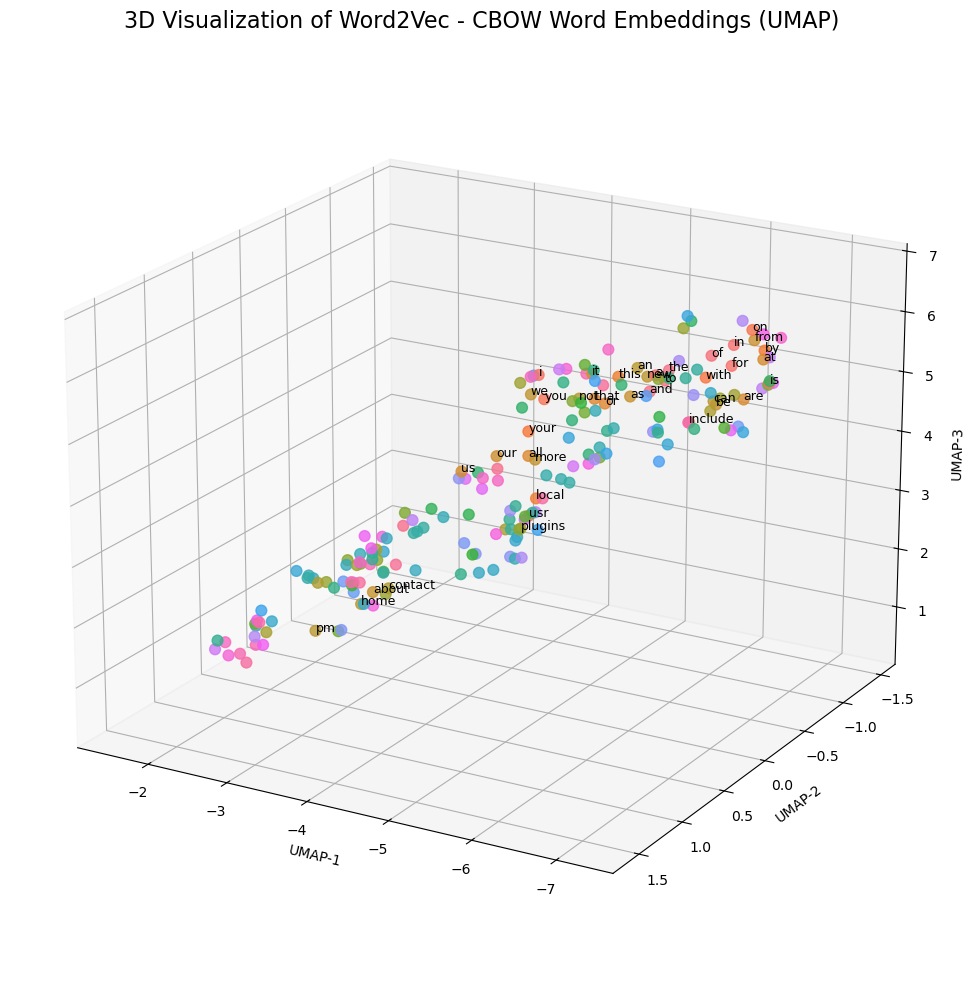

In [35]:
words = list(cbow_model.wv.index_to_key[:200])
vectors = cbow_model.wv[words]

# UMAP dimensionality reduction
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords = umap_model.fit_transform(vectors)

# Color palette
palette = sns.color_palette("husl", len(words))

# Create 3D plot
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    c=palette,
    s=60,
    alpha=0.8
)

# Annotate a subset to avoid clutter
for i, word in enumerate(words[:40]):
    ax.text(
        coords[i,0],
        coords[i,1],
        coords[i,2],
        word,
        fontsize=9
    )

# Axis labels
ax.set_title("3D Visualization of Word2Vec - CBOW Word Embeddings (UMAP)", fontsize=16)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

# Improve viewing angle
ax.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


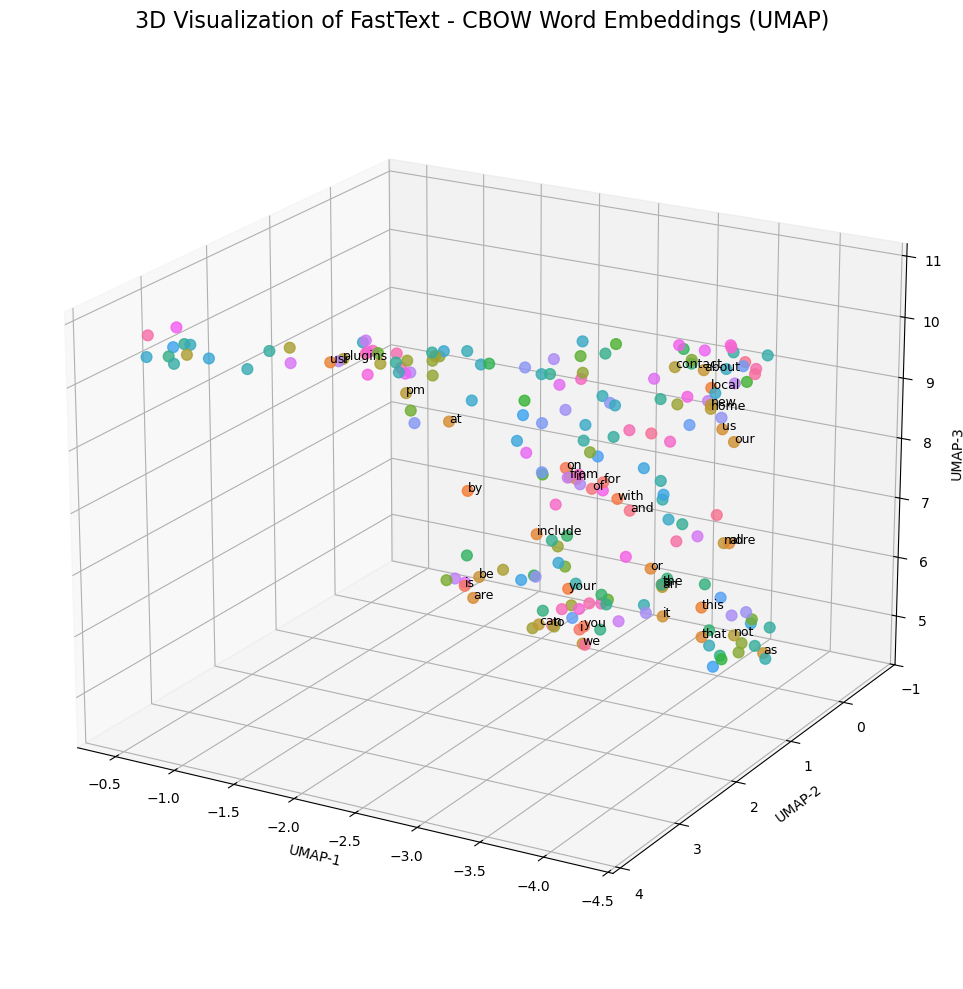

In [36]:
words = list(ftcbow_model.wv.index_to_key[:200])
vectors = ftcbow_model.wv[words]

# UMAP dimensionality reduction
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords = umap_model.fit_transform(vectors)

# Color palette
palette = sns.color_palette("husl", len(words))

# Create 3D plot
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    c=palette,
    s=60,
    alpha=0.8
)

# Annotate a subset to avoid clutter
for i, word in enumerate(words[:40]):
    ax.text(
        coords[i,0],
        coords[i,1],
        coords[i,2],
        word,
        fontsize=9
    )

# Axis labels
ax.set_title("3D Visualization of FastText - CBOW Word Embeddings (UMAP)", fontsize=16)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

# Improve viewing angle
ax.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

## **Part B) Document Embedding & Classification**

Aggregate word embeddings into document vectors and classify web pages:


#### **1. TFIDF-Matrix Construction of Labeled Data**

In [37]:
# Defininfg TFIDF Vectorizer
vectorizer = TfidfVectorizer( 
    max_features= 6000,      # total features, NOT per document
    ngram_range=(1, 2),      # unigrams + bigrams
    max_df=0.50,             # ignore very common words
    min_df=3                 # ignore rare noise
)

In [38]:
# Text Transformation using TFIDF Vectorizer
tfidf_matrix = vectorizer.fit_transform(data['stopwords_removed'])

In [39]:
print("--"*50)
print("Shape of the TFIDF matrix: (Rows, Columns)")
print("--"*50)  
print(tfidf_matrix.shape)
matrix_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("--"*50)
print("TFIDF Matrix as a DataFrame:")
print("--"*50)
matrix_df

----------------------------------------------------------------------------------------------------
Shape of the TFIDF matrix: (Rows, Columns)
----------------------------------------------------------------------------------------------------
(596, 6000)
----------------------------------------------------------------------------------------------------
TFIDF Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,лв,ле,лн,не,нр,рд,ре,редв,рер,рн
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.000000,0.017473,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.025342,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
592,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005547
593,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
594,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


### **2. Using Trained Eembedding Models on Label Corpus**

In [40]:
corpus = data['cleaned_text'].str.split().tolist()
print("Sample tokenized document:", corpus[0][:10])  # Print first 10 tokens of the first document in the corpus

Sample tokenized document: ['fall', 'arrest', 'and', 'work', 'positioning', 'harness', 'allied', 'safety', 'equipment', 'pvt']


**Simple Mean**

In [41]:
def document_vector(model, document):

    mean_vec = np.zeros(model.vector_size)

    word_vectors = [
        model.wv[word]
        for word in document
        if word in model.wv
    ]

    if len(word_vectors) == 0:
        mean_vec = np.zeros(model.vector_size)
    else:
        mean_vec = np.mean(word_vectors, axis=0)

    return mean_vec

**Weighted Average**

In [42]:
def weight_avg(doc_vec, tfidf_vec):
    vec_list = []
    doc_vec_mean = np.mean(doc_vec)
    for i in range(len(tfidf_vec)):
        vec_list.append(doc_vec_mean * tfidf_vec[i])
    
    return vec_list

**Word2Vec - CBOW**

In [43]:
data['doc_vector'] = data['cleaned_text'].apply(
    lambda text: document_vector(cbow_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'cleaned_text', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,doc_vector,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,"[0.09467837, 0.17292112, -0.12327478, 0.089421...",ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,"[0.078129776, -0.27959532, 0.42362767, 0.28091...",BLOG
2,657.0,booking report for bulloch county allongeor...,"[0.017052585, 0.012669359, 0.442803, 0.3358790...",NEWS
3,658.0,is pickleball easier than tennis allracket\n...,"[0.1851944, -0.73329896, 0.5994115, 0.17830227...",BLOG
4,661.0,account executive auto finance greater seatt...,"[0.11225441, -0.24166524, 0.3604454, 0.2562515...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,"[0.032716293, -0.40260315, 0.51344883, 0.32439...",BLOG
592,490.0,kids bike pedals collection d model in bicycle...,"[0.3782197, 0.4413133, -0.3383135, 0.052787136...",ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,"[-0.007631034, -0.32362694, 0.3200746, 0.24390...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[-0.31625676, -0.37196526, -0.06264039, -0.206...",OTHER


In [44]:
col_list = matrix_df.columns
cbow_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    cbow_matrix.append(weighted_avg)

cbow_matrix_df = pd.DataFrame(cbow_matrix, columns=col_list)

cbow_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("CBOW Weighted Average Matrix as a DataFrame:")
print("--"*50)
cbow_matrix_df

----------------------------------------------------------------------------------------------------
CBOW Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,-0.0,-0.0,-0.000000,-0.000101,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
4,0.0,0.0,0.000112,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
592,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000213,ECOMMERCE
593,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**Word2Vec - SkipGram**

In [45]:
data['doc_vector'] = data['cleaned_text'].apply(
    lambda text: document_vector(skipgram_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'cleaned_text', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,doc_vector,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,"[0.02301163, -0.06268784, -0.0015333615, 0.124...",ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,"[0.054188427, 0.008110419, 0.017286511, 0.1517...",BLOG
2,657.0,booking report for bulloch county allongeor...,"[-0.13980329, -0.00065096386, 0.0073429914, 0....",NEWS
3,658.0,is pickleball easier than tennis allracket\n...,"[0.06570807, -0.016486641, 0.00869343, 0.02223...",BLOG
4,661.0,account executive auto finance greater seatt...,"[0.016823271, 0.011423493, 0.020064034, 0.1149...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,"[0.029530806, 0.03487608, 0.0042456784, 0.0887...",BLOG
592,490.0,kids bike pedals collection d model in bicycle...,"[-0.016961742, 0.22340044, 0.16632557, 0.09971...",ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,"[0.0049573546, -0.05115083, 0.005395849, 0.136...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[-0.145918, -0.15890524, 0.059032682, 0.056060...",OTHER


In [46]:
col_list = matrix_df.columns
skipgram_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    skipgram_matrix.append(weighted_avg)

skipgram_matrix_df = pd.DataFrame(skipgram_matrix, columns=col_list)

skipgram_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("Skip-gram Weighted Average Matrix as a DataFrame:")
print("--"*50)
skipgram_matrix_df

----------------------------------------------------------------------------------------------------
Skip-gram Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
2,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,-0.0,-0.0,-0.00000,-0.000001,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
4,0.0,0.0,0.00008,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
592,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000013,ECOMMERCE
593,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.00000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**FastText - CBOW**

In [47]:
data['doc_vector'] = data['cleaned_text'].apply(
    lambda text: document_vector(ftcbow_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'cleaned_text', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,doc_vector,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,"[0.37115124, -0.42336857, -0.4900715, 0.201986...",ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,"[0.3250124, -0.25104013, -0.5662103, 0.1209162...",BLOG
2,657.0,booking report for bulloch county allongeor...,"[0.71760803, -0.37106106, -0.63821995, 0.20253...",NEWS
3,658.0,is pickleball easier than tennis allracket\n...,"[0.6063931, -0.25421292, -1.2021233, 0.0399963...",BLOG
4,661.0,account executive auto finance greater seatt...,"[0.49020422, -0.5257635, -1.0293604, -0.422602...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,"[0.0371114, -0.18077356, -0.4460569, 0.1456038...",BLOG
592,490.0,kids bike pedals collection d model in bicycle...,"[-0.26141968, -1.2677497, 1.0377147, 0.4429884...",ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,"[0.23208915, -0.4427495, -0.32351157, 0.120183...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[1.2484224, -0.10064944, -0.8216275, -0.250359...",OTHER


In [48]:
col_list = matrix_df.columns
ftcbow_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    ftcbow_matrix.append(weighted_avg)

ftcbow_matrix_df = pd.DataFrame(ftcbow_matrix, columns=col_list)

ftcbow_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("FastText-CBOW Weighted Average Matrix as a DataFrame:")
print("--"*50)
ftcbow_matrix_df

----------------------------------------------------------------------------------------------------
FastText-CBOW Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.000000,0.000464,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.000445,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000211,ECOMMERCE
593,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


**FastText - SkipGram**

In [49]:
data['doc_vector'] = data['cleaned_text'].apply(
    lambda text: document_vector(ftskipgram_model, text.split())
)

print("--"*50)
print("Document vectors generated successfully. Sample vector for the first document:")
print("--"*50)
data[['page_id', 'cleaned_text', 'doc_vector', 'manual_label_final']]

----------------------------------------------------------------------------------------------------
Document vectors generated successfully. Sample vector for the first document:
----------------------------------------------------------------------------------------------------


,page_id,cleaned_text,doc_vector,manual_label_final
0,655.0,fall arrest and work positioning harness alli...,"[0.114629656, -0.0936891, 0.14999312, 0.065537...",ECOMMERCE
1,656.0,vermont mountain eats jay peak all mountain ...,"[0.041889388, -0.07077147, 0.23030867, -0.0423...",BLOG
2,657.0,booking report for bulloch county allongeor...,"[0.0914325, -0.036604155, 0.30267265, -0.11475...",NEWS
3,658.0,is pickleball easier than tennis allracket\n...,"[-0.00011648557, -0.0842189, 0.13062342, -0.15...",BLOG
4,661.0,account executive auto finance greater seatt...,"[0.05583437, -0.021214696, 0.12552387, -0.1073...",OTHER
...,...,...,...,...
591,489.0,blog post archives th voyagemystic seaport\n...,"[0.036914743, 0.015318998, 0.18235417, -0.0478...",BLOG
592,490.0,kids bike pedals collection d model in bicycle...,"[-0.10972954, -0.075391285, 0.17325644, 0.0084...",ECOMMERCE
593,491.0,patchcrafts february \npatchcrafts\nthe place ...,"[0.043768685, -0.059591513, 0.20617758, -0.031...",BLOG
594,493.0,fatal error uncaught mysqli sql exception tabl...,"[0.14152329, -0.07932861, 0.36528295, -0.00730...",OTHER


In [50]:
col_list = matrix_df.columns
ftskipgram_matrix = []

for indx in range(len(data)):
    doc_vec = data.loc[indx, 'doc_vector']
    tfidf_vec = matrix_df.loc[indx].values
    weighted_avg = weight_avg(doc_vec, tfidf_vec)

    ftskipgram_matrix.append(weighted_avg)

ftskipgram_matrix_df = pd.DataFrame(ftskipgram_matrix, columns=col_list)

ftskipgram_matrix_df['Category'] = data['manual_label_final'].values

print("--"*50)
print("FastText-Skip-gram Weighted Average Matrix as a DataFrame:")
print("--"*50)
ftskipgram_matrix_df

----------------------------------------------------------------------------------------------------
FastText-Skip-gram Weighted Average Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,aa,ab,ability,able,abs,absolute,absolutely,absolutely essential,abstract,abu,...,ле,лн,не,нр,рд,ре,редв,рер,рн,Category
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,ECOMMERCE
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NEWS
3,0.0,0.0,0.000000,0.000116,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
4,0.0,0.0,0.000014,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,BLOG
592,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000016,ECOMMERCE
593,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,BLOG
594,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,OTHER


### **3. Classification - Train and Compare Random Forest and XGBoost**

In [51]:
# Defining train test libraries
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [55]:
# Train models
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
results_summary = pd.DataFrame({
    'EmbeddingModel': [],
    'Model': [],
    'Accuracy': [],  # Placeholder for accuracy scores
    'Precision': [],  # Placeholder for precision scores
    'Recall': [],  # Placeholder for recall scores
    'F1-Score': []  # Placeholder for F1 scores
})

summary = []

for embedding in ["Word2Vec-CBOW", "Word2Vec Skip-gram", "FastText-CBOW", "FastText Skip-gram"]:
    for model_name, model in [("Random Forest", rf), ("XGBoost", xgb)]:
        if embedding == "Word2Vec-CBOW":
            matrix_df = cbow_matrix_df
        elif embedding == "Word2Vec Skip-gram":
            matrix_df = skipgram_matrix_df
        elif embedding == "FastText-CBOW":
            matrix_df = ftcbow_matrix_df
        else:
            matrix_df = ftskipgram_matrix_df
        
        print(f"Training {model_name} with {embedding} embeddings...")
        print("--"*50)

        X = matrix_df.drop(columns=['Category'])
        
        if model_name == "XGBoost":
            le = LabelEncoder()
            y = le.fit_transform(matrix_df['Category'])
        else:
            y = matrix_df['Category']
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics
        report = classification_report(y_test, y_pred, output_dict=True)['weighted avg']

        # Append results to summary
        summary.append({
            'EmbeddingModel': embedding,
            'Model':          model_name,
            'Accuracy':       accuracy_score(y_test, y_pred),
            'Precision':      report['precision'],
            'Recall':         report['recall'],
            'F1-Score':       report['f1-score']
        })

results_summary = pd.DataFrame(summary)
print("--"*50)
print("Model Evaluation Summary:")
print("--"*50)
print(results_summary)

Training Random Forest with Word2Vec-CBOW embeddings...
----------------------------------------------------------------------------------------------------
Training XGBoost with Word2Vec-CBOW embeddings...
----------------------------------------------------------------------------------------------------


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Training Random Forest with Word2Vec Skip-gram embeddings...
----------------------------------------------------------------------------------------------------
Training XGBoost with Word2Vec Skip-gram embeddings...
----------------------------------------------------------------------------------------------------
Training Random Forest with FastText-CBOW embeddings...
----------------------------------------------------------------------------------------------------


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Training XGBoost with FastText-CBOW embeddings...
----------------------------------------------------------------------------------------------------


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Training Random Forest with FastText Skip-gram embeddings...
----------------------------------------------------------------------------------------------------


/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tejasphanse/miniconda3/envs/nlpenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Training XGBoost with FastText Skip-gram embeddings...
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Model Evaluation Summary:
----------------------------------------------------------------------------------------------------
       EmbeddingModel          Model  Accuracy  Precision    Recall  F1-Score
0       Word2Vec-CBOW  Random Forest  0.483333   0.517228  0.483333  0.461810
1       Word2Vec-CBOW        XGBoost  0.516667   0.556679  0.516667  0.502065
2  Word2Vec Skip-gram  Random Forest  0.491667   0.550986  0.491667  0.472664
3  Word2Vec Skip-gram        XGBoost  0.500000   0.511542  0.500000  0.481854
4       FastText-CBOW  Random Forest  0.491667   0.524926  0.491667  0.466417
5       FastText-CBOW        XGBoost  0.558333   0.559805  0.558333  0.543303
6  FastText Skip-gram  Random Forest  0.450000   0.543188  0.450000  0

Based on the above summary table XGBoost with FastText-CBOW embeddings give us the best trade-off results (Accuracy = 0.558333, Precision = 0.559805, F1-Score = 0.543303)


### **4. Prediction**
Apply best-performing model to predict categories for all unlabeled web pages.